Install & Setup

In [1]:
# Install OCR engine + dependencies
# pytesseract = wrapper Python buat Tesseract OCR
# opencv-python = image preprocessing (grayscale, thresholding, dll)
# easyocr = alternatif OCR berbasis deep learning, biasanya lebih akurat buat teks noisy
!apt-get install -y tesseract-ocr
!pip install pytesseract opencv-python-headless easyocr pandas openpyxl -q

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 24 not upgraded.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 16.0 MB/s eta 0:00:00


Import Library

In [2]:
import cv2                  # image preprocessing (resize, grayscale, denoising)
import pytesseract          # OCR engine utama (baseline)
import easyocr               # OCR alternatif (deep learning based) buat perbandingan
import pandas as pd          # bikin & simpan spreadsheet tracking hasil review
import re                    # regex buat parsing field dari raw text OCR
import json                  # simpan hasil terstruktur
import os
from pathlib import Path
import matplotlib.pyplot as plt   # visualisasi contoh gambar + bounding box

Load Dataset

In [3]:
# Download SROIE dataset (scanned receipts + ground truth)
# Kalau mau custom foto struk sendiri, tinggal upload ke folder ini dan skip cell download
!git clone https://github.com/zzzDavid/ICDAR-2019-SROIE.git
DATA_DIR = "/content/ICDAR-2019-SROIE/data"

# List semua gambar struk yang mau diproses
image_paths = sorted(Path(f"{DATA_DIR}/img").glob("*.jpg"))[:20]  # ambil 20 sample dulu
print(f"Total dokumen yang akan diproses: {len(image_paths)}")

Cloning into 'ICDAR-2019-SROIE'...
remote: Enumerating objects: 2386, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 2386 (delta 18), reused 18 (delta 18), pack-reused 2366 (from 1)
Receiving objects: 100% (2386/2386), 278.64 MiB | 16.12 MiB/s, done.
Resolving deltas: 100% (239/239), done.
Updating files: 100% (1980/1980), done.
Total dokumen yang akan diproses: 20


EDA Singkat — Cek Kualitas Gambar

Ukuran gambar: (1013, 463, 3)


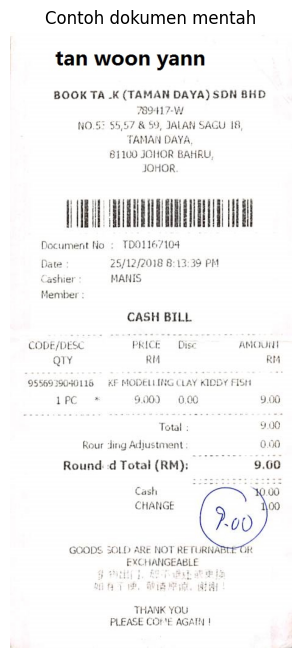

In [4]:
# Cek ukuran & kualitas gambar sebelum OCR, biar tau perlu preprocessing seberapa berat
sample_img = cv2.imread(str(image_paths[0]))
print(f"Ukuran gambar: {sample_img.shape}")

plt.figure(figsize=(6,8))
plt.imshow(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB))
plt.title("Contoh dokumen mentah")
plt.axis('off')
plt.show()

Preprocessing — Baseline

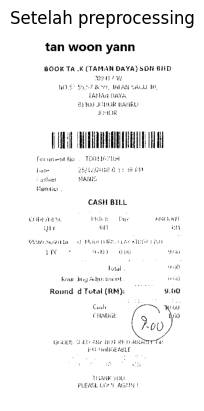

In [5]:
def preprocess_image(img_path):
    """
    Preprocessing dasar sebelum OCR:
    - grayscale: kurangi noise warna
    - thresholding: biar teks lebih kontras dari background
    """
    img = cv2.imread(str(img_path))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)
    return thresh

# Test preprocessing di satu sample
processed = preprocess_image(image_paths[0])
plt.imshow(processed, cmap='gray')
plt.title("Setelah preprocessing")
plt.axis('off')
plt.show()

OCR Extraction — Baseline (Tesseract)

In [6]:
def extract_text_tesseract(img_path):
    """Extract raw text pakai Tesseract (baseline OCR)"""
    processed = preprocess_image(img_path)
    text = pytesseract.image_to_string(processed)
    return text

# Jalankan ke semua sample, simpan hasil mentah
raw_results = {}
for path in image_paths:
    raw_results[path.name] = extract_text_tesseract(path)

# Cek satu contoh hasil
print(raw_results[image_paths[0].name])

tan woon yann

BOOK TAK (TAMAN DAYA) SON AND
TOD EY
NOLS? S547 854, JALAN SACU Rt,
TAMAN DAYA
SH1GU JOHOR GAR

Ji2goR:
Ui MITT A

Poroment Ho TOON Tad

 

 

diate 25/62 B pia Pe
+ ashier MANES
Heniier

CASH BILL

 

COE PES, Peds Tage AIUEL
Quy 1 ian
Osta sweiUTle oa! MULE ILE Lay RIDD
re? ab aa yaa
Total og
four tiny Ader tent wid
Round. d Total (RM): 9.00
Cash 7 Huu

CHANGE hw

  

GOORS. COLL

 

HOE RE FRAT
EXC HAHGEARLE

TIAN Olt
FLEASL COME AGAN |

 



OCR Extraction — Variasi (EasyOCR) untuk Perbandingan

In [7]:
# Inisialisasi EasyOCR reader (bahasa Inggris + Indonesia kalau ada modelnya, default 'en')
reader = easyocr.Reader(['en'], gpu=True)

def extract_text_easyocr(img_path):
    """Extract text pakai EasyOCR (deep learning based, biasanya lebih tahan noise)"""
    result = reader.readtext(str(img_path), detail=0)  # detail=0 -> cuma return teksnya
    return "\n".join(result)

easyocr_results = {}
for path in image_paths:
    easyocr_results[path.name] = extract_text_easyocr(path)

print(easyocr_results[image_paths[0].name])

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argume

tan woon yann
Book TA _k (TAMAN DAYA) SDN BHD
789117-W
NO5 55,57 & $ JALAN SAGU In
TAMAN DAYA;
81100 JOlOR BAHRU;
JOHOR
Doctmerit Ijo
TDO[16/10
Dale
25/12/2018 8 13,39 PM
Casher
MANIS
Menijer
CASH BILL
CODE/OESC
PKICE
Dsc
AMc)UM
QY
Rt
FM
95569 .90-#UI6
KF Modeliimg(LAY KIDDr FISt
PC
9N0 )
Q0
9,O
Total
UO
Rour 'ing Acljustment
0,90
Round d Total (RM):
9.00
Cash
KUO
CHANGE
0o
9.00
GOODS EOLD' AKc NOI RE TURNABT(l'
FXC HANGEABLE
THNK YQU
PLEASE Coi AGAIN


Parsing Jadi Field Terstruktur

In [8]:
def parse_receipt_fields(text):
    """
    Parsing sederhana pakai regex buat extract field kunci dari raw OCR text.
    Ini bagian yang paling sering error -> jadi fokus utama review nanti.
    """
    fields = {}

    # Cari nominal total (pola: TOTAL diikuti angka)
    total_match = re.search(r'(?i)total[:\s]*\$?RM?\s?([\d,]+\.\d{2})', text)
    fields['total'] = total_match.group(1) if total_match else None

    # Cari tanggal (pola umum dd/mm/yyyy atau dd-mm-yyyy)
    date_match = re.search(r'(\d{1,2}[/-]\d{1,2}[/-]\d{2,4})', text)
    fields['date'] = date_match.group(1) if date_match else None

    # Vendor biasanya di baris pertama teks
    lines = [l.strip() for l in text.split('\n') if l.strip()]
    fields['vendor'] = lines[0] if lines else None

    return fields

# Parsing semua hasil Tesseract
parsed_results = {name: parse_receipt_fields(text) for name, text in raw_results.items()}
print(json.dumps(parsed_results[image_paths[0].name], indent=2))

{
  "total": null,
  "date": null,
  "vendor": "tan woon yann"
}


Spreadsheet Tracking untuk Review Manual

In [9]:
# Bikin dataframe tracking buat proses review manual
review_rows = []
for path in image_paths:
    name = path.name
    parsed = parsed_results[name]
    review_rows.append({
        'filename': name,
        'ocr_vendor': parsed['vendor'],
        'ocr_date': parsed['date'],
        'ocr_total': parsed['total'],
        'corrected_vendor': '',   # diisi manual setelah cek gambar asli
        'corrected_date': '',     # diisi manual
        'corrected_total': '',    # diisi manual
        'error_type': '',         # e.g. "wrong_digit", "missed_field", "wrong_layout_read"
        'notes': ''
    })

review_df = pd.DataFrame(review_rows)
review_df.to_excel('/content/review_tracking.xlsx', index=False)
review_df.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,filename,ocr_vendor,ocr_date,ocr_total,corrected_vendor,corrected_date,corrected_total,error_type,notes
0,000.jpg,tan woon yann,None,None,,,,,
1,001.jpg,tan woon yann,None,None,,,,,
2,002.jpg,tan woon yann,12-01-19,None,,,,,
3,003.jpg,tan woon yann,None,None,,,,,
4,004.jpg,tan woon yann,None,None,,,,,


liat gambar

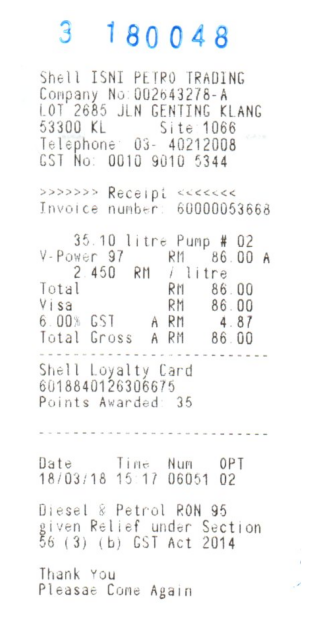

In [10]:
from PIL import Image
import matplotlib.pyplot as plt

# Ganti path ini sesuai hasil "find" di atas
img_path = image_paths[19]  # Menggunakan path yang benar dari list image_paths
img = Image.open(img_path)

plt.figure(figsize=(6,8))
plt.imshow(img)
plt.axis('off')
plt.show()

Hitung Akurasi Setelah Review Manual

In [13]:
reviewed_df = pd.read_excel('/content/review_tracking_filled.xlsx')

def calc_field_accuracy(df, field):
    """Hitung persentase field yang OCR-nya benar (sama dengan hasil koreksi manual)"""
    correct = (df[f'ocr_{field}'].astype(str).str.strip() ==
               df[f'corrected_{field}'].astype(str).str.strip()).sum()
    return correct / len(df) * 100

for field in ['vendor', 'date', 'total']:
    acc = calc_field_accuracy(reviewed_df, field)
    print(f"Akurasi field '{field}': {acc:.1f}%")

# Distribusi jenis error yang paling sering muncul
error_counts = reviewed_df['error_type'].value_counts()
print("\nDistribusi Error:")
print(error_counts)

Akurasi field 'vendor': 20.0%
Akurasi field 'date': 35.0%
Akurasi field 'total': 5.0%

Distribusi Error:
error_type
wrong_field_source + missed_field                     6
garbled_text                                          3
wrong_field_source (vendor) + missed_field (total)    2
partial_read (vendor) + missed_field (total)          2
correct                                               2
correct (total)                                       1
wrong_field_source                                    1
missed_field                                          1
partial_read (vendor) + missed_field (date, total)    1
garbled_text (vendor) + missed_field (date)           1
Name: count, dtype: int64


In [14]:
def normalize_number(val):
    """
    Normalisasi angka biar '3.90 (text) dan 3.9 (float) dianggap sama.
    Convert semua ke float dulu, baru dibandingkan.
    """
    if pd.isna(val) or val == '':
        return None
    try:
        # Bersihin karakter non-angka yang mungkin nyelip (spasi, simbol mata uang, dll)
        cleaned = str(val).replace(',', '').strip()
        return round(float(cleaned), 2)  # bulatkan 2 desimal biar konsisten
    except ValueError:
        return None

def calc_field_accuracy_normalized(df, field):
    """Versi akurasi yang udah handle perbedaan format angka vs teks"""
    if field == 'total':
        ocr_vals = df[f'ocr_{field}'].apply(normalize_number)
        corrected_vals = df[f'corrected_{field}'].apply(normalize_number)
        correct = (ocr_vals == corrected_vals).sum()
    else:
        # Field non-angka (vendor, date) tetap pakai perbandingan string biasa
        correct = (df[f'ocr_{field}'].astype(str).str.strip() ==
                   df[f'corrected_{field}'].astype(str).str.strip()).sum()
    return correct / len(df) * 100

# Hitung ulang akurasi total pakai fungsi yang udah dibenerin
for field in ['vendor', 'date', 'total']:
    acc = calc_field_accuracy_normalized(reviewed_df, field)
    print(f"Akurasi field '{field}' (normalized): {acc:.1f}%")

Akurasi field 'vendor' (normalized): 20.0%
Akurasi field 'date' (normalized): 35.0%
Akurasi field 'total' (normalized): 5.0%


# Kode: Regex Improved buat Total

In [15]:
def parse_total_improved(text):
    """
    Regex v2: nangkep lebih banyak variasi label total yang muncul di struk.
    Prioritas: cari label yang paling 'final' dulu (Rounded/Grand Total),
    baru fallback ke label 'Total' polos kalau yang lain gak ketemu.
    """
    # Daftar pola dari yang paling spesifik/final ke yang paling umum
    patterns = [
        r'(?i)total\s*rounded[:\s]*RM?\s?([\d,]+\.\d{2})',
        r'(?i)rounded\s*total\s*\(?RM\)?[:\s]*([\d,]+\.\d{2})',
        r'(?i)grand\s*total[:\s]*RM?\s?([\d,]+\.\d{2})',
        r'(?i)total\s*amt\s*rounded[:\s]*([\d,]+\.\d{2})',
        r'(?i)total\s*sales\s*\(inclusive.*?\)[:\s]*([\d,]+\.\d{2})',
        r'(?i)total\s*gross\s*A?\s*RM?\s?([\d,]+\.\d{2})',
        r'(?i)^total[:\s]*RM?\s?([\d,]+\.\d{2})',  # fallback: "Total" polos
    ]

    for pattern in patterns:
        match = re.search(pattern, text, re.MULTILINE)
        if match:
            return match.group(1).replace(',', '')
    return None

# Jalankan regex v2 ke semua raw OCR text yang udah ada dari sebelumnya
ocr_total_v2 = {}
for filename, text in raw_results.items():
    ocr_total_v2[filename] = parse_total_improved(text)

# Masukin hasil v2 ke dataframe review
reviewed_df['ocr_total_v2'] = reviewed_df['filename'].map(ocr_total_v2)
reviewed_df[['filename', 'ocr_total', 'ocr_total_v2', 'corrected_total']]

,filename,ocr_total,ocr_total_v2,corrected_total
0,000.jpg,NaN,None,9.00
1,001.jpg,NaN,None,60.30
2,002.jpg,NaN,93.96,33.90
3,003.jpg,NaN,None,80.90
4,004.jpg,NaN,None,30.90
5,005.jpg,NaN,None,31.00
6,006.jpg,NaN,None,327.00
7,007.jpg,NaN,None,20.00
8,008.jpg,NaN,None,112.45
9,009.jpg,NaN,None,26.60


# Hitung akurasi baseline vs improved

In [16]:
def calc_field_accuracy_normalized(df, ocr_col, corrected_col):
    """Bandingin dua kolom angka, dengan normalisasi tipe data"""
    ocr_vals = df[ocr_col].apply(normalize_number)
    corrected_vals = df[corrected_col].apply(normalize_number)
    correct = (ocr_vals == corrected_vals).sum()
    return correct / len(df) * 100

acc_baseline = calc_field_accuracy_normalized(reviewed_df, 'ocr_total', 'corrected_total')
acc_improved = calc_field_accuracy_normalized(reviewed_df, 'ocr_total_v2', 'corrected_total')

print(f"Akurasi total (baseline regex): {acc_baseline:.1f}%")
print(f"Akurasi total (improved regex): {acc_improved:.1f}%")

Akurasi total (baseline regex): 5.0%
Akurasi total (improved regex): 5.0%


In [17]:
# Lihat semua hasil regex v2 buat tiap file
print(reviewed_df[['filename', 'ocr_total_v2', 'corrected_total']].to_string())

   filename ocr_total_v2  corrected_total
0   000.jpg         None             9.00
1   001.jpg         None            60.30
2   002.jpg        93.96            33.90
3   003.jpg         None            80.90
4   004.jpg         None            30.90
5   005.jpg         None            31.00
6   006.jpg         None           327.00
7   007.jpg         None            20.00
8   008.jpg         None           112.45
9   009.jpg         None            26.60
10  010.jpg        14.10            14.10
11  011.jpg         None            15.00
12  012.jpg         None            15.90
13  013.jpg         None            15.00
14  014.jpg         None            32.70
15  015.jpg         None            15.90
16  016.jpg         None            73.00
17  017.jpg         None            39.80
18  018.jpg         None            73.00
19  019.jpg         None            86.00


In [18]:
# Cek apakah raw_results masih ada isinya
print(f"Jumlah item di raw_results: {len(raw_results)}")
print(raw_results.get('000.jpg', 'TIDAK ADA')[:300])  # print 300 karakter pertama

Jumlah item di raw_results: 20
tan woon yann

BOOK TAK (TAMAN DAYA) SON AND
TOD EY
NOLS? S547 854, JALAN SACU Rt,
TAMAN DAYA
SH1GU JOHOR GAR

Ji2goR:
Ui MITT A

Poroment Ho TOON Tad

 

 

diate 25/62 B pia Pe
+ ashier MANES
Heniier

CASH BILL

 

COE PES, Peds Tage AIUEL
Quy 1 ian
Osta sweiUTle oa! MULE ILE Lay RIDD
re? ab aa ya


benerin thresholding

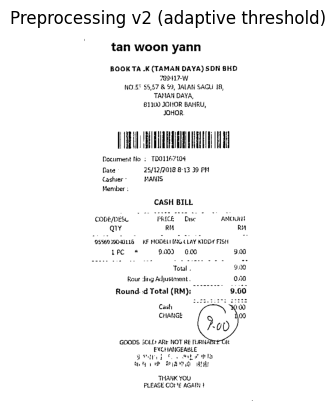

In [19]:
def preprocess_image_v2(img_path):
    """
    Preprocessing v2: pakai adaptive thresholding (auto-adjust per area gambar),
    bukan fixed value. Lebih tahan variasi pencahayaan antar struk.
    """
    img = cv2.imread(str(img_path))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Denoising dulu biar gambar lebih bersih sebelum threshold
    denoised = cv2.fastNlMeansDenoising(gray, h=10)

    # Adaptive threshold: nilai threshold dihitung otomatis per blok area gambar
    thresh = cv2.adaptiveThreshold(
        denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, blockSize=31, C=15
    )
    return thresh

# Test ke satu sample dulu, bandingin visual sama versi lama
processed_v2 = preprocess_image_v2(image_paths[0])
plt.imshow(processed_v2, cmap='gray')
plt.title("Preprocessing v2 (adaptive threshold)")
plt.axis('off')
plt.show()

In [20]:
# Re-run OCR pakai preprocessing v2
def extract_text_tesseract_v2(img_path):
    processed = preprocess_image_v2(img_path)
    text = pytesseract.image_to_string(processed)
    return text

raw_results_v2 = {}
for path in image_paths:
    raw_results_v2[path.name] = extract_text_tesseract_v2(path)

# Cek hasilnya di sample yang tadi rusak parah
print(raw_results_v2['000.jpg'])

tan woon yann

BOOK TA .K (TAMAN DAYA) SDN SKD
FEO
NOLS? 55,57 & $9, JALAN SAGU 18,
TAMAN DAYA,
81100 JOHOR BAHRU,
JOHOR

[AU

Document No: TD01167104

 

 

Date 25/12/2018 8-13 39 PH
Cashiers MANIS
Member :
CASH BILL
cODE/DES. PRICE Disc = AQUI
ay Rt RH
“95569. 306 KF MODEL ite cay oor FIsn ~
LPC * © 9.009 0.00 9.00
Total .

Rour Jing Adjustment.

Round. -d Total (RM)

 

Cash
CHANGE

00 ”

GOODS SOLD ARE NOT RE TURNAI Ke
EXCHANGEABLE

 

Cele hh
ay wb SAG MAT

THANK YOU
PLEASE COME AGAIN t



In [21]:
# Jalankan preprocessing + OCR v2 ke SEMUA gambar (bukan cuma satu sample)
raw_results_v2 = {}
for path in image_paths:
    raw_results_v2[path.name] = extract_text_tesseract_v2(path)

print(f"Selesai proses {len(raw_results_v2)} dokumen dengan preprocessing v2")

Selesai proses 20 dokumen dengan preprocessing v2


In [22]:
# Re-run regex baseline DAN improved di atas data v2
ocr_total_baseline_v2 = {}
ocr_total_improved_v2 = {}

for filename, text in raw_results_v2.items():
    # Regex baseline (dari Blok 8 awal)
    total_match = re.search(r'(?i)total[:\s]*\$?RM?\s?([\d,]+\.\d{2})', text)
    ocr_total_baseline_v2[filename] = total_match.group(1) if total_match else None

    # Regex improved (yang kita bikin tadi)
    ocr_total_improved_v2[filename] = parse_total_improved(text)

reviewed_df['ocr_total_baseline_v2'] = reviewed_df['filename'].map(ocr_total_baseline_v2)
reviewed_df['ocr_total_improved_v2'] = reviewed_df['filename'].map(ocr_total_improved_v2)

reviewed_df[['filename', 'ocr_total', 'ocr_total_baseline_v2', 'ocr_total_improved_v2', 'corrected_total']]

,filename,ocr_total,ocr_total_baseline_v2,ocr_total_improved_v2,corrected_total
0,000.jpg,NaN,None,None,9.00
1,001.jpg,NaN,None,None,60.30
2,002.jpg,NaN,None,None,33.90
3,003.jpg,NaN,None,None,80.90
4,004.jpg,NaN,None,None,30.90
5,005.jpg,NaN,None,None,31.00
6,006.jpg,NaN,None,None,327.00
7,007.jpg,NaN,None,None,20.00
8,008.jpg,NaN,None,None,112.45
9,009.jpg,NaN,None,None,26.60


In [23]:
# Hitung akurasi buat 3 kombinasi
acc_v1_baseline = calc_field_accuracy_normalized(reviewed_df, 'ocr_total', 'corrected_total')
acc_v2_baseline = calc_field_accuracy_normalized(reviewed_df, 'ocr_total_baseline_v2', 'corrected_total')
acc_v2_improved = calc_field_accuracy_normalized(reviewed_df, 'ocr_total_improved_v2', 'corrected_total')

print(f"Preprocessing v1 + Regex baseline : {acc_v1_baseline:.1f}%")
print(f"Preprocessing v2 + Regex baseline : {acc_v2_baseline:.1f}%")
print(f"Preprocessing v2 + Regex improved : {acc_v2_improved:.1f}%")

Preprocessing v1 + Regex baseline : 5.0%
Preprocessing v2 + Regex baseline : 5.0%
Preprocessing v2 + Regex improved : 5.0%


In [24]:
# Print semua kolom total sekaligus buat lihat pola mismatch-nya
print(reviewed_df[['filename', 'ocr_total_baseline_v2', 'ocr_total_improved_v2', 'corrected_total']].to_string())

   filename ocr_total_baseline_v2 ocr_total_improved_v2  corrected_total
0   000.jpg                  None                  None             9.00
1   001.jpg                  None                  None            60.30
2   002.jpg                  None                  None            33.90
3   003.jpg                  None                  None            80.90
4   004.jpg                  None                  None            30.90
5   005.jpg                  None                  None            31.00
6   006.jpg                  None                  None           327.00
7   007.jpg                  None                  None            20.00
8   008.jpg                  None                  None           112.45
9   009.jpg                  None                  None            26.60
10  010.jpg                 14.10                 14.10            14.10
11  011.jpg                  None                  None            15.00
12  012.jpg                  None                  

In [25]:
# Test langsung fungsi normalize_number dengan beberapa contoh
print(normalize_number("9.00"))
print(normalize_number(9.0))
print(normalize_number("9.009"))  # ini kayak yang muncul di raw text 000.jpg tadi
print(normalize_number(None))

# Test perbandingan manual
print(normalize_number("9.00") == normalize_number(9.0))

9.0
9.0
9.01
None
True


In [26]:
# Print teks lengkap 000.jpg biar kelihatan struktur baris di sekitar kata "Total"
print(raw_results_v2['000.jpg'])

tan woon yann

BOOK TA .K (TAMAN DAYA) SDN SKD
FEO
NOLS? 55,57 & $9, JALAN SAGU 18,
TAMAN DAYA,
81100 JOHOR BAHRU,
JOHOR

[AU

Document No: TD01167104

 

 

Date 25/12/2018 8-13 39 PH
Cashiers MANIS
Member :
CASH BILL
cODE/DES. PRICE Disc = AQUI
ay Rt RH
“95569. 306 KF MODEL ite cay oor FIsn ~
LPC * © 9.009 0.00 9.00
Total .

Rour Jing Adjustment.

Round. -d Total (RM)

 

Cash
CHANGE

00 ”

GOODS SOLD ARE NOT RE TURNAI Ke
EXCHANGEABLE

 

Cele hh
ay wb SAG MAT

THANK YOU
PLEASE COME AGAIN t



In [27]:
# Ambil raw text 000.jpg, coba tes semua pattern regex satu-satu manual
text_sample = raw_results_v2['000.jpg']

patterns_to_test = [
    r'(?i)total\s*rounded[:\s]*RM?\s?([\d,]+\.\d{2})',
    r'(?i)rounded\s*total\s*\(?RM\)?[:\s]*([\d,]+\.\d{2})',
    r'(?i)total[:\s]*\$?RM?\s?([\d,]+\.\d{2})',
]

for i, pattern in enumerate(patterns_to_test):
    match = re.search(pattern, text_sample, re.MULTILINE)
    print(f"Pattern {i}: {'MATCH -> ' + match.group(1) if match else 'NO MATCH'}")

Pattern 0: NO MATCH
Pattern 1: NO MATCH
Pattern 2: NO MATCH


Lapis 1: Perbaiki extraction Vendor (skip header berulang)

In [32]:
# Daftar header/watermark yang diketahui berulang di dataset (dari temuan manual kamu)
KNOWN_HEADER_NOISE = ['tan woon yann', 'tan chay yee']

def extract_vendor_improved(text):
    """
    Extract vendor dengan skip baris header/watermark yang udah diketahui,
    lalu ambil baris pertama SETELAHNYA yang keliatan seperti nama bisnis
    (huruf kapital dominan, panjang wajar, bukan alamat/nomor).
    """
    lines = [l.strip() for l in text.split('\n') if l.strip()]

    for line in lines:
        line_lower = line.lower().strip()
        # Skip kalau ini header noise yang udah dikenal
        if any(noise in line_lower for noise in KNOWN_HEADER_NOISE):
            continue
        # Skip baris yang keliatan bukan nama bisnis (angka dominan, alamat, dsb)
        if re.match(r'^\d', line) or len(line) < 3:
            continue
        # Kandidat pertama yang lolos filter = nama vendor
        return line
    return None

# Test ke semua data v2
vendor_improved = {}
for filename, text in raw_results_v2.items():
    vendor_improved[filename] = extract_vendor_improved(text)

reviewed_df['ocr_vendor_improved'] = reviewed_df['filename'].map(vendor_improved)
reviewed_df[['filename', 'ocr_vendor', 'ocr_vendor_improved', 'corrected_vendor']]

,filename,ocr_vendor,ocr_vendor_improved,corrected_vendor
0,000.jpg,tan woon yann,BOOK TA .K (TAMAN DAYA) SDN SKD,OOK TA.K (TAMAN DAYA) SDN BHD
1,001.jpg,tan woon yann,TRDAH GIFT & HOME TECO,INDAH GIFT & HOME DECO
2,002.jpg,tan woon yann,MR O.1.¥. (JOHOR) SDN SHD,MR D.I.Y (Johor) SDN BHD
3,003.jpg,tan woon yann,YONGFATT ENTERPRISE,YONGFATT ENTERPRISE
4,004.jpg,tan woon yann,MKD Toy. Md SON MID,MR D.I.Y. (M) SDN BHD
5,005.jpg,tan chay yee,~ Cash Bill T “Oi-2a3008-~ ~~,ABC HO TRADING
6,006.jpg,tan chay yee,SOON HUAT MACHINERY ENTERPRISE,SOON HUAT MACHINERY ENTERPRISE
7,007.jpg,tan chay yee,"MA HOTR {SUA 1 REG ) SD, it,",S.H.H. MOTOR (SUNGAI RENGIT) SDN BHD
8,008.jpg,Ad>ndige,Ad>ndige,PERNIAGAAN ZHENG HUI
9,009.jpg,UL !,° ¥,Gerbang Alaf Restaurants Sdn Bhd


Lapis 2: Perbaiki extraction Total (cari dalam radius, bukan strict same-line)

In [33]:
def extract_total_improved_v3(text):
    """
    Cari label total, lalu scan beberapa baris SETELAHNYA (bukan cuma baris sama)
    buat nemuin angka desimal terdekat. Prioritas label 'final' dulu.
    """
    lines = text.split('\n')
    priority_labels = ['total rounded', 'rounded total', 'grand total',
                        'total amt rounded', 'total sales', 'total gross', 'total']

    for label in priority_labels:
        for i, line in enumerate(lines):
            if label in line.lower():
                # Cari angka desimal di baris ini DAN 2 baris setelahnya
                search_zone = ' '.join(lines[i:i+3])
                match = re.search(r'([\d,]+\.\d{2})', search_zone)
                if match:
                    val = match.group(1).replace(',', '')
                    # Validasi: angka harus masuk akal (bukan 0.00 doang atau kepanjangan)
                    try:
                        f = float(val)
                        if 0.5 <= f <= 100000:
                            return val
                    except ValueError:
                        continue
    return None

total_improved_v3 = {}
for filename, text in raw_results_v2.items():
    total_improved_v3[filename] = extract_total_improved_v3(text)

reviewed_df['ocr_total_improved_v3'] = reviewed_df['filename'].map(total_improved_v3)
reviewed_df[['filename', 'ocr_total', 'ocr_total_improved_v3', 'corrected_total']]

,filename,ocr_total,ocr_total_improved_v3,corrected_total
0,000.jpg,NaN,None,9.00
1,001.jpg,NaN,40.01,60.30
2,002.jpg,NaN,50.00,33.90
3,003.jpg,NaN,80.90,80.90
4,004.jpg,NaN,30.91,30.90
5,005.jpg,NaN,None,31.00
6,006.jpg,NaN,327.00,327.00
7,007.jpg,NaN,20.00,20.00
8,008.jpg,NaN,706.40,112.45
9,009.jpg,NaN,26.60,26.60


Hitung akurasi setelah Lapis 1 & 2

In [34]:
acc_vendor_v3 = calc_field_accuracy_normalized_text(reviewed_df, 'ocr_vendor_improved', 'corrected_vendor') if 'calc_field_accuracy_normalized_text' in dir() else None

# Kalau belum ada fungsi buat text field, pakai ini:
def calc_field_accuracy_text(df, ocr_col, corrected_col):
    correct = (df[ocr_col].astype(str).str.strip().str.lower() ==
               df[corrected_col].astype(str).str.strip().str.lower()).sum()
    return correct / len(df) * 100

acc_vendor_v3 = calc_field_accuracy_text(reviewed_df, 'ocr_vendor_improved', 'corrected_vendor')
acc_total_v3 = calc_field_accuracy_normalized(reviewed_df, 'ocr_total_improved_v3', 'corrected_total')

print(f"Vendor - baseline: 20.0% -> improved: {acc_vendor_v3:.1f}%")
print(f"Total  - baseline: 5.0%  -> improved: {acc_total_v3:.1f}%")

Vendor - baseline: 20.0% -> improved: 35.0%
Total  - baseline: 5.0%  -> improved: 25.0%


Visualisasi Perbandingan Error


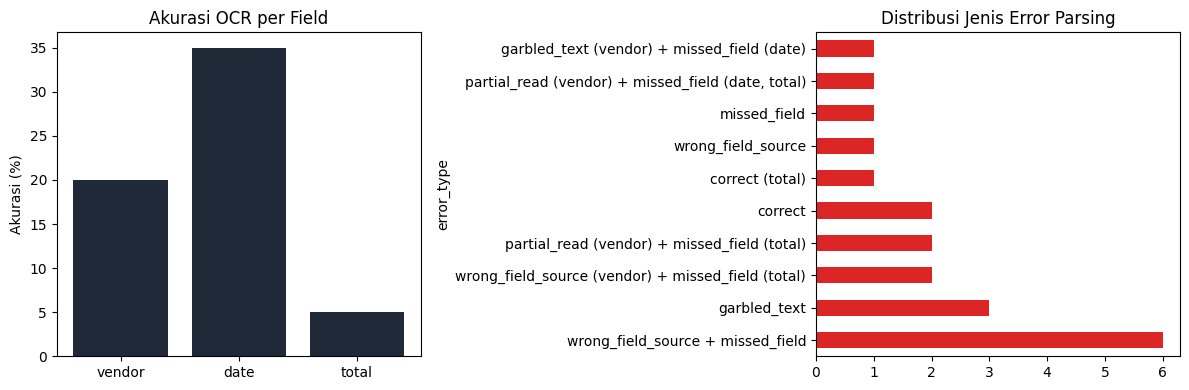

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Akurasi per field
accuracies = [calc_field_accuracy(reviewed_df, f) for f in ['vendor', 'date', 'total']]
axes[0].bar(['vendor', 'date', 'total'], accuracies, color='#1f2937')
axes[0].set_title('Akurasi OCR per Field')
axes[0].set_ylabel('Akurasi (%)')

# Distribusi jenis error
error_counts.plot(kind='barh', ax=axes[1], color='#dc2626')
axes[1].set_title('Distribusi Jenis Error Parsing')

plt.tight_layout()
plt.savefig('/content/error_analysis.png', dpi=150)
plt.show()

Error Feedback Report

In [36]:
# Generate summary report otomatis dari hasil review
report = f"""
# OCR Parsing QA Report

## Ringkasan
- Total dokumen direview: {len(reviewed_df)}
- Akurasi field 'vendor': {calc_field_accuracy(reviewed_df, 'vendor'):.1f}%
- Akurasi field 'date': {calc_field_accuracy(reviewed_df, 'date'):.1f}%
- Akurasi field 'total': {calc_field_accuracy(reviewed_df, 'total'):.1f}%

## Pola Error Paling Umum
{error_counts.to_string()}

## Rekomendasi Perbaikan
- (isi manual berdasarkan temuan: misal "regex total gagal baca kalau ada simbol mata uang custom")
"""

with open('/content/qa_report.md', 'w') as f:
    f.write(report)

print(report)


# OCR Parsing QA Report

## Ringkasan
- Total dokumen direview: 20
- Akurasi field 'vendor': 20.0%
- Akurasi field 'date': 35.0%
- Akurasi field 'total': 5.0%

## Pola Error Paling Umum
error_type
wrong_field_source + missed_field                     6
garbled_text                                          3
wrong_field_source (vendor) + missed_field (total)    2
partial_read (vendor) + missed_field (total)          2
correct                                               2
correct (total)                                       1
wrong_field_source                                    1
missed_field                                          1
partial_read (vendor) + missed_field (date, total)    1
garbled_text (vendor) + missed_field (date)           1

## Rekomendasi Perbaikan
- (isi manual berdasarkan temuan: misal "regex total gagal baca kalau ada simbol mata uang custom")



In [37]:
# Print isi asli kolom ocr_total dan corrected_total, plus tipe datanya
print(reviewed_df[['filename', 'ocr_total', 'corrected_total']].to_string())
print()
print("Tipe data ocr_total:", reviewed_df['ocr_total'].dtype)
print("Tipe data corrected_total:", reviewed_df['corrected_total'].dtype)

   filename  ocr_total  corrected_total
0   000.jpg        NaN             9.00
1   001.jpg        NaN            60.30
2   002.jpg        NaN            33.90
3   003.jpg        NaN            80.90
4   004.jpg        NaN            30.90
5   005.jpg        NaN            31.00
6   006.jpg        NaN           327.00
7   007.jpg        NaN            20.00
8   008.jpg        NaN           112.45
9   009.jpg        NaN            26.60
10  010.jpg       14.1            14.10
11  011.jpg        NaN            15.00
12  012.jpg        NaN            15.90
13  013.jpg        NaN            15.00
14  014.jpg        NaN            32.70
15  015.jpg        NaN            15.90
16  016.jpg        NaN            73.00
17  017.jpg        NaN            39.80
18  018.jpg        NaN            73.00
19  019.jpg        NaN            86.00

Tipe data ocr_total: float64
Tipe data corrected_total: float64


In [42]:
# Zip semua isi folder /content (kecuali sample_data bawaan Colab yang gak perlu)
!zip -r semua_file_project.zip /content -x "/content/sample_data/*"

  adding: content/ (stored 0%)
  adding: content/.config/ (stored 0%)
  adding: content/.config/gce (stored 0%)
  adding: content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db (deflated 97%)
  adding: content/.config/default_configs.db (deflated 98%)
  adding: content/.config/.last_update_check.json (deflated 23%)
  adding: content/.config/config_sentinel (stored 0%)
  adding: content/.config/.last_opt_in_prompt.yaml (stored 0%)
  adding: content/.config/.last_survey_prompt.yaml (stored 0%)
  adding: content/.config/logs/ (stored 0%)
  adding: content/.config/logs/2026.08.10/ (stored 0%)
  adding: content/.config/logs/2026.08.10/13.26.19.834999.log (deflated 56%)
  adding: content/.config/logs/2026.08.10/13.26.03.888211.log (deflated 58%)
  adding: content/.config/logs/2026.08.10/13.25.25.328016.log (deflated 58%)
  adding: content/.config/logs/2026.08.10/13.25.43.233148.log (deflated 86%)
  adding: content/.config/logs/2026.08.10/13.26.18.998373.log (deflated 

In [43]:
from google.colab import files
files.download('/content/semua_file_project.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>